# Frequency model

This notebook predicts how often a policy claims, as claims per policy-year, with two models:

- a **Poisson GLM** on banded rating factors, the standard tool in pricing teams;
- a **LightGBM** gradient-boosted model with a Poisson objective on the raw factors.

All choices (banding, GBM settings, the comparison between the two) are made on the training data with 5-fold cross-validation. The test set is scored once, in the last section, after both models are fixed. Every metric and plot is exposure-weighted.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.model_selection import KFold

from pricing.data import PROJECT_ROOT, RANDOM_SEED, build_policy_table, load_raw, split_train_test
from pricing.evaluation import (
    balance, calibration_table, deviance_explained, gini, lorenz_curve, one_way_table, poisson_deviance,
)
from pricing.features import (
    BANDS, GLM_FACTORS, add_glm_bands, band_labels, base_levels, gbm_matrix, glm_design_matrix, glm_levels,
)
from pricing.gbm import FrequencyGBM, cv_poisson_gbm
from pricing.glm import fit_poisson_glm, predict, relativities
from pricing.plots import plot_calibration, plot_lorenz, plot_relativities, save, set_style

set_style()
pl.Config.set_tbl_rows(80)
pl.Config.set_float_precision(4)
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

In [2]:
freq_raw, sev_raw = load_raw()
train, test = split_train_test(build_policy_table(freq_raw, sev_raw))
y_train, e_train = train["ClaimNb"].to_numpy(), train["Exposure"].to_numpy()
train_rate = y_train.sum() / e_train.sum()
print(f"Train: {train.height:,} policies, {e_train.sum():,.0f} policy-years, frequency {train_rate:.4f}")

Train: 542,410 policies, 286,764 policy-years, frequency 0.0733


## 1. How exposure enters the models

A policy on risk for three months has a quarter of the chance to claim of a full-year policy. Both models predict a **rate per policy-year** and multiply it by exposure to get expected claims:

$$E[\text{claims}] = \text{exposure} \times \text{rate}(x) \quad\Longleftrightarrow\quad \log E[\text{claims}] = \log(\text{exposure}) + \log \text{rate}(x)$$

The term $\log(\text{exposure})$ is an **offset**: it is added to the model's linear predictor with a coefficient fixed at 1, not estimated. In the GLM it is passed as `offset`. In LightGBM it is passed as `init_score`, the starting value each policy's prediction is built up from. Both models therefore fit claim counts directly, with exposure setting the scale.

## 2. GLM: banding the rating factors

A GLM gives each band of a factor its own multiplier, so continuous factors are grouped into bands a pricing team could read and defend. The choices, made from the training one-ways, are recorded in `pricing/features.py`:

In [3]:
pl.DataFrame({"factor": list(BANDS), "bands": [", ".join(band_labels(b)) for b in BANDS.values()]})

factor,bands
str,str
"""DrivAge""","""18-19, 20-21, 22-23, 24-25, 26…"
"""BonusMalus""","""50, 51-59, 60-69, 70-79, 80-89…"
"""VehAge""","""0, 1-5, 6-12, 13-17, 18+"""
"""VehPower""","""4, 5, 6, 7, 8, 9, 10, 11, 12+"""
"""Density""","""1-9, 10-31, 32-99, 100-315, 31…"


- **DrivAge**: two-year bands up to 25, where frequency falls steeply, then wider bands where it is nearly flat.
- **BonusMalus**: 50 on its own (57% of exposure), then bands of 10. Individual values are not monotone: values on the 5%-a-year discount path from 100 (95, 90, ... 57, 54, 51) have much lower frequency than values in between, which are only reachable after a claim. Ordered bands average over this. The GBM, which sees the raw value, can pick it up.
- **VehAge**: new cars, then 1-5 and 6-12 (roughly flat), then two bands for older cars, where frequency falls.
- **Density**: half-decade bands on a log scale, since frequency rises roughly with log density. **Area** is left out because it is a coarser banding of the same thing.
- **VehBrand, VehGas, Region**: used as they are.

The **base level** of each factor is the one with the most training exposure, so each relativity reads as "compared with the most common risk".

In [4]:
train_b = add_glm_bands(train)
levels = glm_levels(train_b)
base = base_levels(train_b)
X_train_glm = glm_design_matrix(train_b, levels, base)
print("Base levels:", base)
print("Design matrix:", X_train_glm.shape)

Base levels: {'DrivAge': '40-49', 'BonusMalus': '50', 'VehAge': '1-5', 'VehPower': '6', 'Density': '100-315', 'VehBrand': 'B1', 'VehGas': 'Regular', 'Region': 'R24'}
Design matrix: (542410, 69)


## 3. GLM: fit and relativities

The Poisson GLM with a log link fits

$$\log E[\text{claims}] = \log(\text{exposure}) + \beta_0 + \sum_j \beta_j x_j$$

Exponentiating a coefficient gives a **relativity**: the multiplier on the claim rate for that level compared with the base level, with every other factor held fixed. The price for a policy is the base rate times the product of its relativities, which is why GLMs are easy to put into a rating table.

In [5]:
glm = fit_poisson_glm(X_train_glm, y_train, e_train)
print(f"Base rate (all factors at base level): {np.exp(glm.params['const']):.4f} claims per policy-year")
rel = relativities(glm, levels, base)
rel

Base rate (all factors at base level): 0.0505 claims per policy-year


factor,level,is_base,relativity,lower_95,upper_95
str,str,bool,f64,f64,f64
"""DrivAge""","""18-19""",false,1.2463,1.0850,1.4316
"""DrivAge""","""20-21""",false,0.9558,0.8662,1.0547
"""DrivAge""","""22-23""",false,0.7998,0.7302,0.8760
"""DrivAge""","""24-25""",false,0.6448,0.5908,0.7038
"""DrivAge""","""26-29""",false,0.5687,0.5350,0.6046
"""DrivAge""","""30-39""",false,0.6707,0.6436,0.6988
"""DrivAge""","""40-49""",true,1.0000,1.0000,1.0000
"""DrivAge""","""50-59""",false,0.9959,0.9567,1.0368
"""DrivAge""","""60-69""",false,0.9206,0.8737,0.9700


### Relativities against one-ways

The one-way relativity is what the raw data shows for a factor on its own. The GLM relativity is the same factor's effect after adjusting for all the others. Where the two differ, part of the one-way effect belonged to another factor.

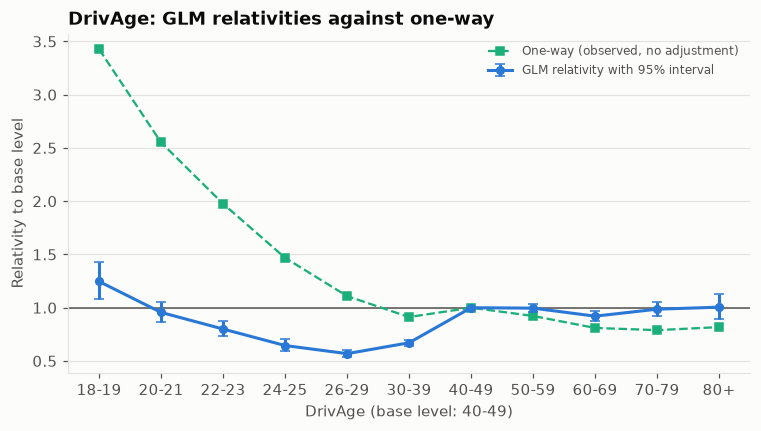

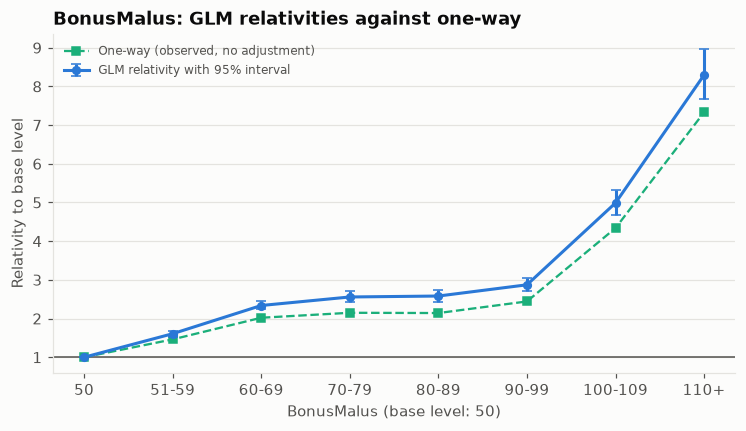

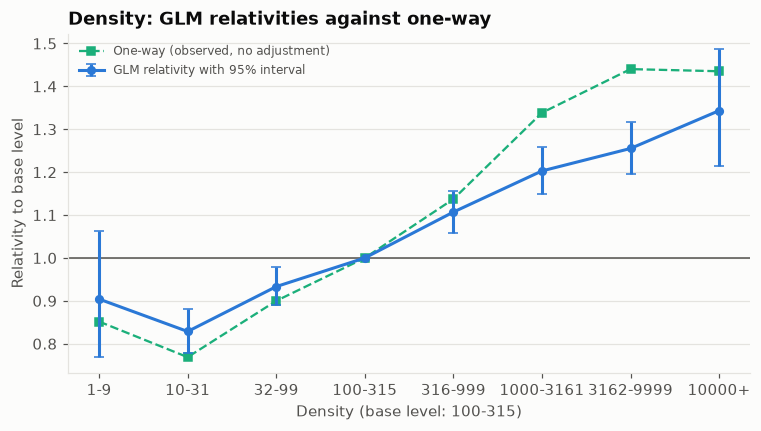

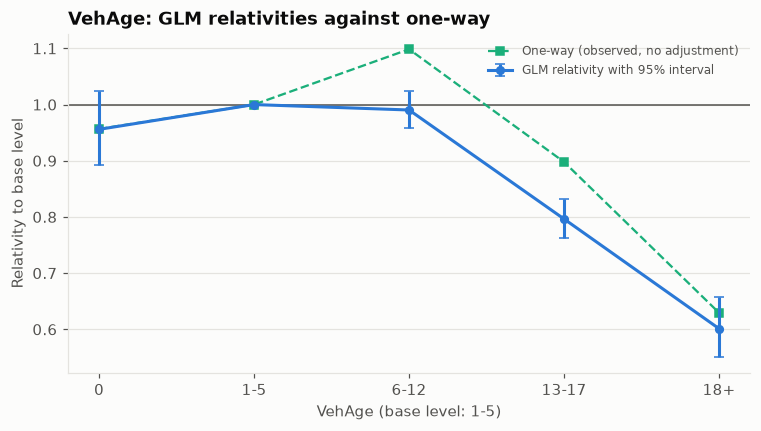

In [6]:
for factor in ["DrivAge", "BonusMalus", "Density", "VehAge"]:
    ow = one_way_table(train_b, factor)
    fig = plot_relativities(rel, ow, factor, band_labels(BANDS[factor]))
    save(fig, f"freq_glm_relativities_{factor.lower()}")
    plt.show()

The driver age chart shows the overlap found in the EDA. On its own, the 18-19 band claims about four times as often as the 40-49 base. Once BonusMalus is in the model, the GLM puts the age effect for 18-19 at about 1.25, and drivers aged 26-29 come out below the base. Most of the raw young-driver effect is carried by their BonusMalus: new drivers start at 100 and have had no time to earn a discount.

The BonusMalus relativities move less once driver age is in, so BonusMalus is carrying most of the shared effect. The relativities for thin bands (BonusMalus 110+, DrivAge 80+) have wide intervals, as expected with little exposure behind them.

## 4. GBM: settings

LightGBM builds the prediction as a sum of small decision trees, each correcting the errors of the ones before. It uses the raw factors: exact ages, BonusMalus values and densities, with brand, fuel and region as native categorical features.

Exposure goes in through `init_score = log(exposure) + log(training frequency)`. The first term is the offset, exactly as in the GLM. The second is there because LightGBM skips its usual "start from the average" step whenever an `init_score` is supplied, and without it the first few hundred trees would be spent learning the overall level.

The alternative is to model the rate (claims / exposure) with exposure as the sample weight. For the Poisson loss this gives the same gradients and so the same model; `init_score` is used here because it mirrors the GLM offset.

Tuning is kept modest: learning rate 0.05, a small grid over tree size, and the number of trees chosen by early stopping in 5-fold cross-validation on the training data.

In [7]:
X_train_gbm = gbm_matrix(train)
grid = [{"num_leaves": nl, "min_data_in_leaf": md} for nl in (15, 31, 63) for md in (100, 500)]
cv_rows = []
for params in grid:
    rounds, score = cv_poisson_gbm(X_train_gbm, y_train, e_train, params)
    cv_rows.append({**params, "trees": rounds, "cv_poisson_nll": score})
cv_results = pl.DataFrame(cv_rows).sort("cv_poisson_nll")
cv_results

num_leaves,min_data_in_leaf,trees,cv_poisson_nll
i64,i64,i64,f64
63,100,207,0.1533
31,100,298,0.1533
31,500,327,0.1534
63,500,197,0.1534
15,100,610,0.1534
15,500,711,0.1534


The score is LightGBM's Poisson negative log-likelihood per policy. It differs from Poisson deviance only by a term that depends on the data, not on the model, so ranking settings by one gives the same order as the other. The differences between settings are small, in the fourth decimal place, so the choice matters little. The best setting is used.

In [8]:
best = cv_results.row(0, named=True)
gbm_params = {"num_leaves": best["num_leaves"], "min_data_in_leaf": best["min_data_in_leaf"]}
gbm_rounds = best["trees"]
print(gbm_params, gbm_rounds, "trees")

{'num_leaves': 63, 'min_data_in_leaf': 100} 207 trees


## 5. Comparison on the training data (cross-validated)

Both models are refitted on each of 5 folds of the training data and scored on the fold they did not see. This compares them without touching the test set. The GBM uses the settings chosen above, which were picked on the same folds, so its result here is slightly optimistic.

Metrics, all exposure-weighted:

- **Poisson deviance** per policy-year: how far predicted claim counts are from observed ones, measured in the way that suits count data. Lower is better.
- **Deviance explained**: the share of a no-factor model's deviance (one rate for everyone) that the model removes.
- **Gini**: how well the model ranks policies from low to high risk. 0 is random ranking.
- **Balance**: total predicted claims divided by total observed claims.

In [9]:
def score(claims, rate, exposure):
    return {
        "poisson_deviance": poisson_deviance(claims, rate, exposure),
        "deviance_explained": deviance_explained(claims, rate, exposure, train_rate),
        "gini": gini(claims, rate, exposure),
        "balance": balance(claims, rate, exposure),
    }


oof = {"GLM": np.zeros(train.height), "GBM": np.zeros(train.height)}
for fold_train, fold_valid in KFold(5, shuffle=True, random_state=RANDOM_SEED).split(X_train_glm):
    tr_b = train_b[fold_train]
    fold_levels, fold_base = glm_levels(tr_b), base_levels(tr_b)
    fold_glm = fit_poisson_glm(glm_design_matrix(tr_b, fold_levels, fold_base), y_train[fold_train], e_train[fold_train])
    oof["GLM"][fold_valid] = predict(fold_glm, glm_design_matrix(train_b[fold_valid], fold_levels, fold_base))

    fold_gbm = FrequencyGBM(gbm_params, gbm_rounds).fit(
        X_train_gbm.iloc[fold_train], y_train[fold_train], e_train[fold_train]
    )
    oof["GBM"][fold_valid] = fold_gbm.predict_rate(X_train_gbm.iloc[fold_valid])

pl.DataFrame([{"model": m, **score(y_train, oof[m], e_train)} for m in oof])

model,poisson_deviance,deviance_explained,gini,balance
str,f64,f64,f64,f64
"""GLM""",0.4528,0.0489,0.2961,1.0000
"""GBM""",0.4448,0.0657,0.3300,0.9992


On the cross-validated training data the GBM has lower deviance and a higher Gini than the GLM. Both balance on the training data, as they should: a Poisson GLM with an intercept matches total observed claims exactly on the data it is fitted to.

Deviance explained is small for both models, around 5 to 7%. That is normal for claim frequency. Most of the variation in whether a given policy claims in a given year is chance, which no rating factor can predict. What a pricing model can do is separate groups whose average rates differ, and the Gini and calibration measure that better than deviance explained does.

## 6. Final models and the test set

Both models are refitted on the full training data with the settings above and then scored once on the test set. Nothing is changed after this point.

In [10]:
gbm = FrequencyGBM(gbm_params, gbm_rounds).fit(X_train_gbm, y_train, e_train)

test_b = add_glm_bands(test)
y_test, e_test = test["ClaimNb"].to_numpy(), test["Exposure"].to_numpy()
pred_test = {
    "GLM": predict(glm, glm_design_matrix(test_b, levels, base)),
    "GBM": gbm.predict_rate(gbm_matrix(test)),
}
test_scores = pl.DataFrame([{"model": m, **score(y_test, pred_test[m], e_test)} for m in pred_test])
test_scores

model,poisson_deviance,deviance_explained,gini,balance
str,f64,f64,f64,f64
"""GLM""",0.4625,0.0478,0.2931,0.9731
"""GBM""",0.4543,0.0648,0.3261,0.9704


The test results match the cross-validated ones closely, so neither model has overfitted its training data. The GBM's deviance is about 2% lower and its Gini about 0.03 higher.

Both models show a balance of about 0.97 on the test set. This is not a fault in either model: the test set's observed frequency (7.54%) happens to be higher than the training set's (7.33%), and 7.33 / 7.54 = 0.97. Both models are balanced on the data they were fitted to, and the gap is ordinary variation between random samples.

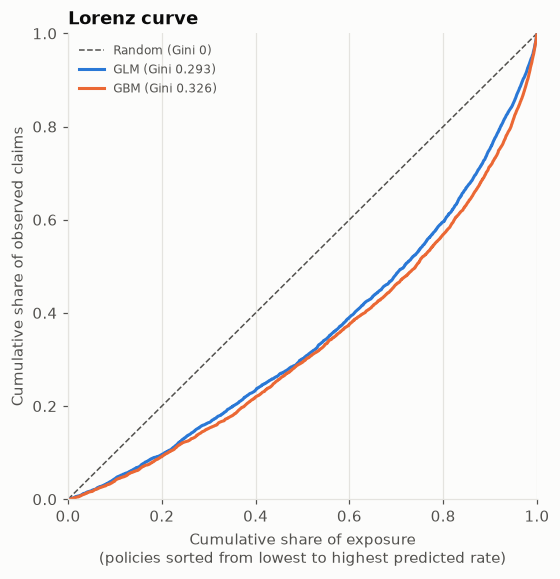

In [11]:
curves = {m: lorenz_curve(y_test, p, e_test) for m, p in pred_test.items()}
fig = plot_lorenz(curves, {m: gini(y_test, p, e_test) for m, p in pred_test.items()})
save(fig, "freq_lorenz_test")
plt.show()

The Lorenz curve sorts test policies from lowest to highest predicted rate and plots the share of claims they account for against their share of exposure. A model that ranks risk well puts few claims in its lowest-predicted policies, so its curve sags further below the diagonal. The Gini is the area between the diagonal and the curve, doubled.

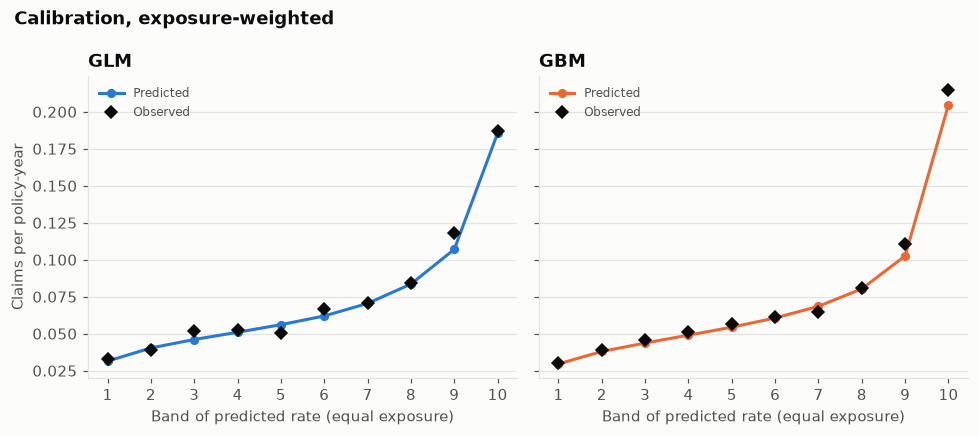

In [12]:
calib = {m: calibration_table(y_test, p, e_test) for m, p in pred_test.items()}
fig = plot_calibration(calib)
save(fig, "freq_calibration_test")
plt.show()

In [13]:
calib["GLM"].select("band", "weight", "observed_mean", "predicted_mean").rename({"weight": "exposure"}).join(
    calib["GBM"].select("band", "observed_mean", "predicted_mean"), on="band", suffix="_gbm"
)

band,exposure,observed_mean,predicted_mean,observed_mean_gbm,predicted_mean_gbm
i64,f64,f64,f64,f64,f64
1,7159.2366,0.0332,0.0315,0.0299,0.0296
2,7159.1714,0.0388,0.0404,0.0391,0.0380
3,7160.3120,0.0521,0.0461,0.0455,0.0437
4,7159.6558,0.0527,0.0510,0.0511,0.0490
5,7159.6184,0.0506,0.0561,0.0563,0.0544
6,7159.0515,0.0668,0.0620,0.0613,0.0606
7,7160.1744,0.0707,0.0705,0.0647,0.0685
8,7159.4045,0.0844,0.0836,0.0806,0.0803
9,7159.2238,0.1180,0.1070,0.1105,0.1026


Each band holds a tenth of the test exposure, sorted by the model's own predicted rate. A well-calibrated model has predicted and observed frequency close together in every band, not only on average.

Both models follow the observed frequency across the bands. The largest gaps are in the ninth band for the GLM (predicted 10.7%, observed 11.8%) and the top band for both. The GBM's top band reaches a higher observed frequency (21.5% against the GLM's 18.7%), which is what its higher Gini looks like here: it concentrates more of the high-risk policies in the band it predicts as highest.

## 7. Save predictions and models for later notebooks

Test-set predictions are saved for the pure premium and commercial analysis notebooks, so the test set does not have to be rescored.

In [14]:
test.select("IDpol", "ClaimNb", "Exposure").with_columns(
    pl.Series("freq_glm", pred_test["GLM"]), pl.Series("freq_gbm", pred_test["GBM"])
).write_parquet(PROCESSED / "frequency_test_predictions.parquet")

glm.remove_data()
with open(PROCESSED / "frequency_glm.pkl", "wb") as fh:
    pickle.dump({"results": glm, "levels": levels, "base": base}, fh)
gbm.booster.save_model(PROCESSED / "frequency_gbm.txt")
with open(PROCESSED / "frequency_gbm_meta.pkl", "wb") as fh:
    pickle.dump({"params": gbm_params, "rounds": gbm_rounds, "base_rate": gbm.base_rate}, fh)